# Composite Scores + Filtering

Build composite scores from a decorrelated subset of metrics (on the scaled+aligned table), re-evaluate against the singles, then filter low-confidence samples and re-rank.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config.datasets import cfg
from config.paths import RAW_DATA_DIR, METRIC_YAML
from config.analysis import QUALITY_THRESHOLDS, QUALITY_MODE, WINDOW_FAMILIES
from preprocessing.align import load_metric_directions
from analysis.distributions import get_numeric_metrics
from analysis.evaluation import calculate_all_metrics, plot_top_metrics_bar, load_metric_families, get_family
from analysis.composite import select_decorrelated_metrics, build_composites, quality_filter

In [10]:
base = RAW_DATA_DIR / cfg.name          # base tables live under data/raw/<name>/
raw = pd.read_csv(base / "merged.csv")
scaled_aligned = pd.read_csv(base / "merged_scaled_aligned.csv")

# Evaluate on LABELLED rows only (exclude designs, binder == "?") so metrics can be scored,
# and drop window families (net_charge, surface_hydrophobicity) from monotonic scoring --
# consistent with run_evaluation / run_composite.
families = load_metric_families(METRIC_YAML)
directions = load_metric_directions(METRIC_YAML)
lab = pd.to_numeric(raw["binder"], errors="coerce").isin([0, 1]).to_numpy()
metrics = [m for m in get_numeric_metrics(raw) if get_family(m, families) not in WINDOW_FAMILIES]

rankings = calculate_all_metrics(raw[lab], metrics, directions)
rankings.head(10)

,metric,raw_roc,aligned_roc,pr_auc,f1,precision,recall,opt_threshold,opt_threshold_raw,direction,note
14,cf_ipsae,0.6933,0.6933,0.7389,0.6780,0.7407,0.6250,0.7251,0.7251,1,
16,cf_lis,0.6715,0.6715,0.7186,0.6667,0.5000,1.0000,0.2466,0.2466,1,
20,pred_lddt,0.6669,0.6669,0.7153,0.6714,0.6184,0.7344,0.8635,0.8635,1,
10,cf_pae,0.3392,0.6608,0.7133,0.6667,0.5000,1.0000,-4.9377,4.9377,-1,
19,pred_ilddt,0.6543,0.6543,0.7038,0.6632,0.4961,1.0000,0.1270,0.1270,1,
4,af3_ipsae,0.6552,0.6552,0.6927,0.6821,0.5413,0.9219,0.0852,0.0852,1,
13,cf_iplddt,0.6536,0.6536,0.6888,0.6632,0.4961,1.0000,0.6955,0.6955,1,
15,cf_pdockq2,0.6495,0.6495,0.6806,0.6702,0.5039,1.0000,0.0842,0.0842,1,
0,af3_pae,0.3487,0.6513,0.6739,0.6632,0.4961,1.0000,-5.5550,5.5550,-1,
24,esmfold2_pae,0.3916,0.6084,0.6602,0.6702,0.5039,1.0000,-7.6135,7.6135,-1,


## Composite scores

In [11]:
combine_cols = select_decorrelated_metrics(rankings, scaled_aligned[lab], top_n=20, method="family")
print("combining:", combine_cols)

composed = build_composites(scaled_aligned[lab], combine_cols, rankings=rankings)
composite_cols = [c for c in composed.columns if c.startswith("composite_")]

# NOTE: this re-evaluates the composite on the SAME rows used to build/weight it (in-sample),
# so these composite numbers are OPTIMISTIC. The leakage-free estimate is produced by
# run_composite.py (out-of-fold CV -> composite_cv_eval.csv). Kept here as a quick visual only.
combined = calculate_all_metrics(composed, metrics + composite_cols, {})
combined["is_composite"] = combined["metric"].isin(composite_cols)
combined.head(20)[["metric", "pr_auc", "aligned_roc", "f1", "is_composite"]]

combining: ['cf_ipsae', 'cf_lis', 'pred_lddt', 'cf_pae', 'pred_ilddt', 'cf_pdockq2', 'af3_ptm', 'esmfold2_ipae', 'af3_iptm']


,metric,pr_auc,aligned_roc,f1,is_composite
51,composite_product,0.7394,0.6714,0.6667,True
14,cf_ipsae,0.7389,0.6933,0.6780,False
50,composite_weighted,0.7346,0.6805,0.6780,True
49,composite_mean,0.7322,0.6788,0.6780,True
16,cf_lis,0.7186,0.6715,0.6667,False
20,pred_lddt,0.7153,0.6669,0.6714,False
10,cf_pae,0.7133,0.6608,0.6667,False
19,pred_ilddt,0.7038,0.6543,0.6632,False
4,af3_ipsae,0.6927,0.6552,0.6821,False
13,cf_iplddt,0.6888,0.6536,0.6632,False


            metric  pr_auc  aligned_roc     f1
 composite_product  0.7394       0.6714 0.6667
composite_weighted  0.7346       0.6805 0.6780
    composite_mean  0.7322       0.6788 0.6780


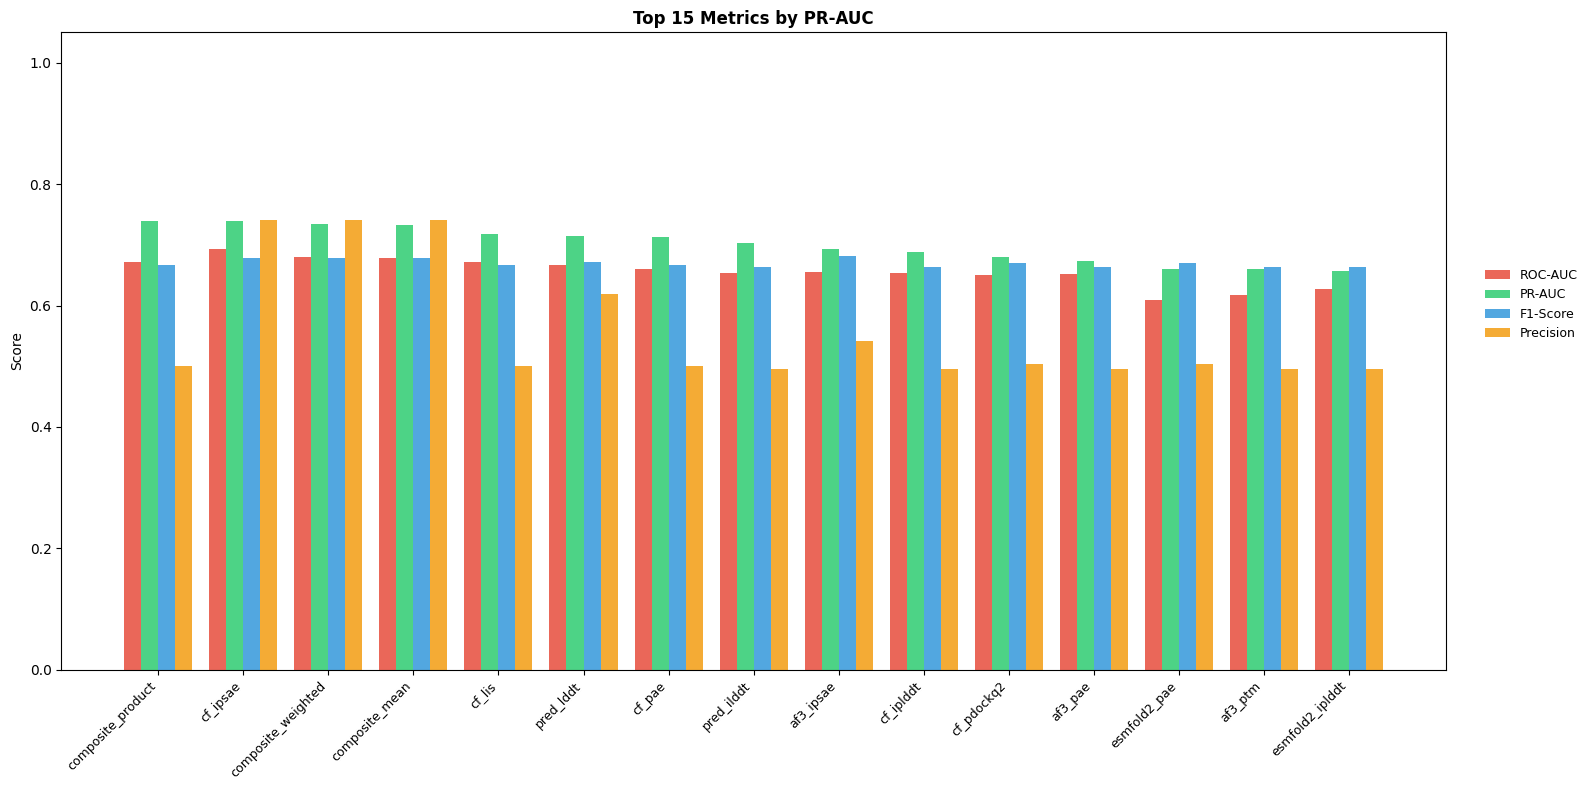

In [12]:
# where do the composites land vs the best singles?
print(combined[combined["is_composite"]][["metric", "pr_auc", "aligned_roc", "f1"]].to_string(index=False))
plot_top_metrics_bar(combined, top_n=15, show=True)

## Filter -> re-rank

In [13]:
flagged = quality_filter(raw[lab], QUALITY_THRESHOLDS, directions, mode=QUALITY_MODE)
print(flagged["quality_flag"].value_counts().to_dict())
kept = flagged[flagged["quality_flag"] == "ok"]

filtered_rankings = calculate_all_metrics(kept, metrics, directions)

before = rankings[["metric", "pr_auc"]].rename(columns={"pr_auc": "pr_auc_all"})
after = filtered_rankings[["metric", "pr_auc"]].rename(columns={"pr_auc": "pr_auc_filtered"})
compare = before.merge(after, on="metric").sort_values("pr_auc_all", ascending=False)
compare["delta"] = (compare["pr_auc_filtered"] - compare["pr_auc_all"]).round(4)
compare.head(15)

{'ok': 113, 'low_confidence': 16}


,metric,pr_auc_all,pr_auc_filtered,delta
0,cf_ipsae,0.7389,0.7654,0.0265
1,cf_lis,0.7186,0.7434,0.0248
2,pred_lddt,0.7153,0.7387,0.0234
3,cf_pae,0.7133,0.7399,0.0266
4,pred_ilddt,0.7038,0.7275,0.0237
5,af3_ipsae,0.6927,0.7112,0.0185
6,cf_iplddt,0.6888,0.7110,0.0222
7,cf_pdockq2,0.6806,0.7019,0.0213
8,af3_pae,0.6739,0.6959,0.0220
9,esmfold2_pae,0.6602,0.6828,0.0226


## Model-agreement diagnostics

Folded in from the exploratory tooling: how much do the models agree, and does constraining / templating change the scores?

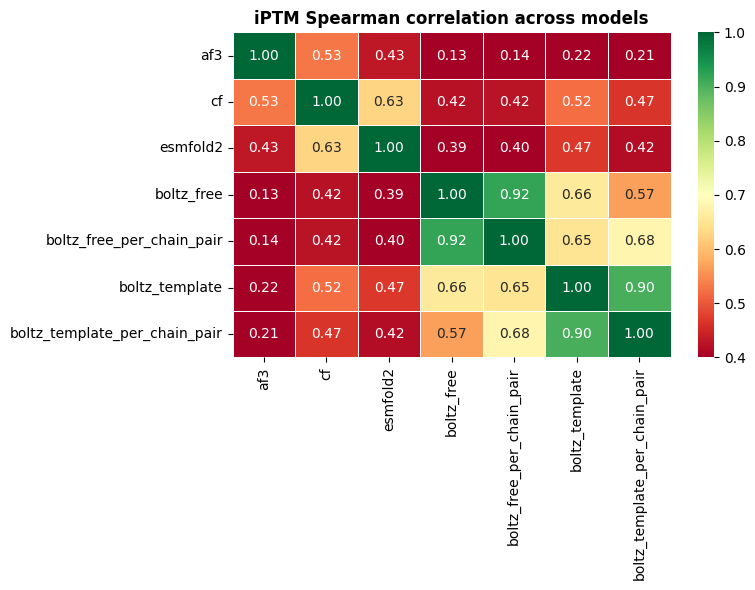

In [14]:
iptm_cols = [c for c in raw.columns if c.endswith("_iptm")]
if iptm_cols:
    corr = raw[iptm_cols].corr(method="spearman")
    corr.index = corr.columns = [c.replace("_iptm", "") for c in iptm_cols]
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0.4, vmax=1.0, linewidths=0.5, ax=ax)
    ax.set_title("iPTM Spearman correlation across models", fontweight="bold")
    plt.tight_layout(); plt.show()